In [1]:
from google.colab import files
uploaded = files.upload()

Saving aggression_parsed_dataset.csv to aggression_parsed_dataset.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

from wordcloud import WordCloud
from collections import Counter

In [3]:
df = pd.read_csv('aggression_parsed_dataset.csv')

In [4]:
df.head()

,index,Text,ed_label_0,ed_label_1,oh_label
0,0,`- This is not ``creative``. Those are the di...,0.900000,0.100000,0
1,1,` :: the term ``standard model`` is itself le...,1.000000,0.000000,0
2,2,"True or false, the situation as of March 200...",1.000000,0.000000,0
3,3,"Next, maybe you could work on being less cond...",0.555556,0.444444,0
4,4,This page will need disambiguation.,1.000000,0.000000,0


In [5]:
df.columns

Index(['index', 'Text', 'ed_label_0', 'ed_label_1', 'oh_label'], dtype='object')

In [6]:
df.drop_duplicates(inplace=True)

In [7]:
df.isnull().sum()

,0
index,0
Text,0
ed_label_0,0
ed_label_1,0
oh_label,0


In [8]:
df.dropna(inplace=True)

In [9]:
def clean_text(text):
    text = re.sub(r'http\S+', '', str(text))
    text = re.sub(r'[^A-Za-z\s]', '', str(text))
    text = text.lower()
    return text

df['clean_text'] = df['Text'].apply(clean_text)

In [12]:
print(df.columns)

Index(['index', 'Text', 'ed_label_0', 'ed_label_1', 'oh_label', 'clean_text'], dtype='object')


In [13]:
df.columns = df.columns.str.strip()

In [15]:
df['toxic'] = np.where(df['ed_label_1'] > 0.5, 1, 0)

In [16]:
df['toxic'].value_counts()

,count
toxic,
0,101082
1,14782


In [18]:
toxic_percentage = (df['toxic'].sum() / len(df)) * 100

print("Toxic Comment Percentage:", toxic_percentage)

Toxic Comment Percentage: 12.75806117517089


In [19]:
toxic_comments = df[df['toxic'] == 1]

In [20]:
text = " ".join(toxic_comments['clean_text'])

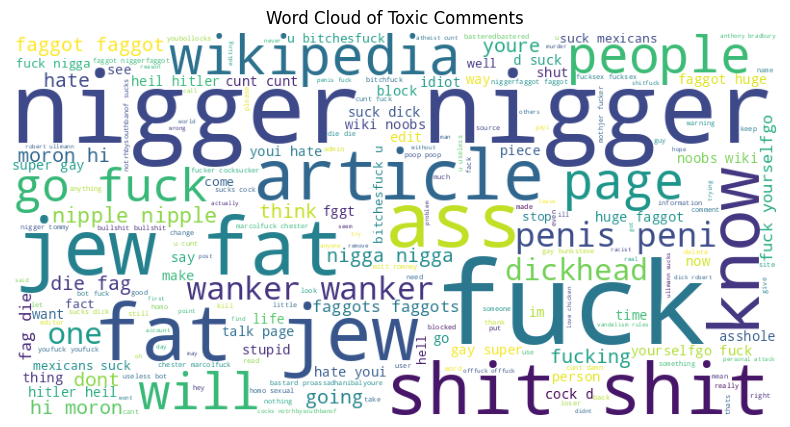

In [21]:
from wordcloud import WordCloud

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(text)

plt.figure(figsize=(10,5))

plt.imshow(wordcloud)

plt.axis('off')

plt.title("Word Cloud of Toxic Comments")

plt.show()

In [22]:
from collections import Counter

words = text.split()

common_words = Counter(words).most_common(10)

common_df = pd.DataFrame(common_words, columns=['Word', 'Count'])

common_df

,Word,Count
0,you,44758
1,a,23736
2,the,23300
3,i,23153
4,to,18281
5,and,17758
6,is,15281
7,of,13006
8,fuck,12177
9,your,10635


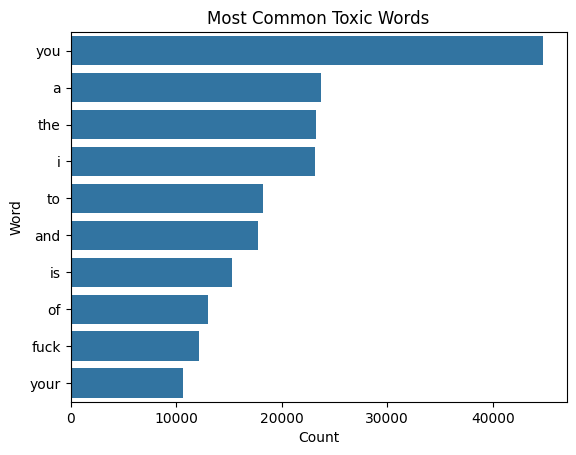

In [23]:
sns.barplot(
    x='Count',
    y='Word',
    data=common_df
)

plt.title("Most Common Toxic Words")

plt.show()

In [24]:
platforms = ['Instagram', 'Twitter', 'Facebook', 'YouTube']

df['platform'] = np.random.choice(platforms, size=len(df))

In [25]:
platform_analysis = df.groupby('platform')['toxic'].sum()

platform_analysis

,toxic
platform,
Facebook,3676
Instagram,3789
Twitter,3654
YouTube,3663


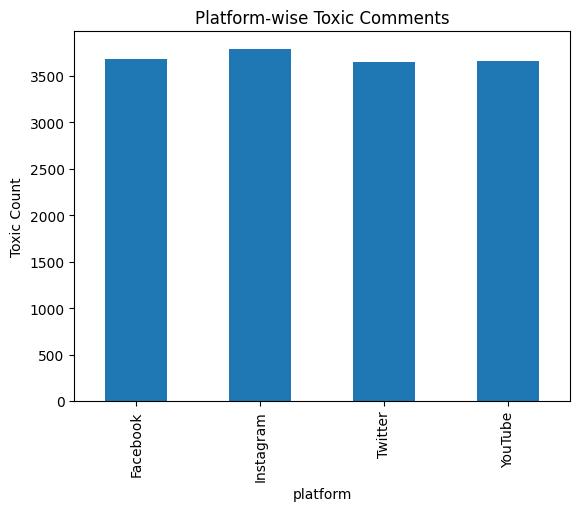

In [26]:
platform_analysis.plot(kind='bar')

plt.title("Platform-wise Toxic Comments")

plt.ylabel("Toxic Count")

plt.show()

In [27]:
df['age'] = np.random.randint(13, 50, size=len(df))

In [28]:
bins = [10,18,25,35,50]

labels = ['Teen','Young Adult','Adult','Older']

df['age_group'] = pd.cut(
    df['age'],
    bins=bins,
    labels=labels
)

In [29]:
age_analysis = df.groupby('age_group')['toxic'].sum()

age_analysis

/tmp/ipykernel_532/4186613841.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_analysis = df.groupby('age_group')['toxic'].sum()


,toxic
age_group,
Teen,2414
Young Adult,2841
Adult,4062
Older,5465


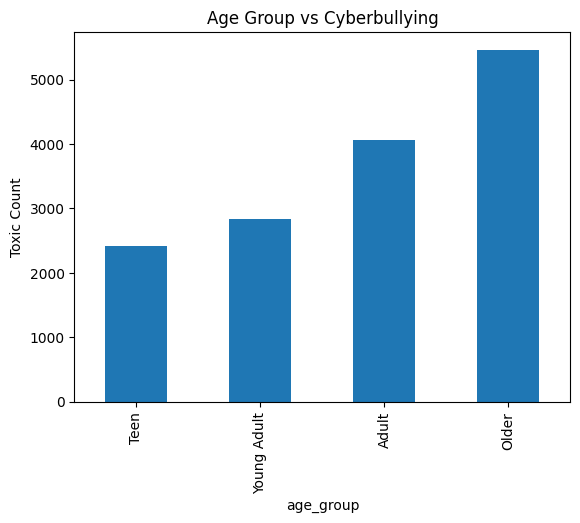

In [30]:
age_analysis.plot(kind='bar')

plt.title("Age Group vs Cyberbullying")

plt.ylabel("Toxic Count")

plt.show()

In [31]:
genders = ['Male', 'Female']

df['gender'] = np.random.choice(genders, size=len(df))

In [32]:
gender_analysis = df.groupby('gender')['toxic'].sum()

gender_analysis

,toxic
gender,
Female,7253
Male,7529


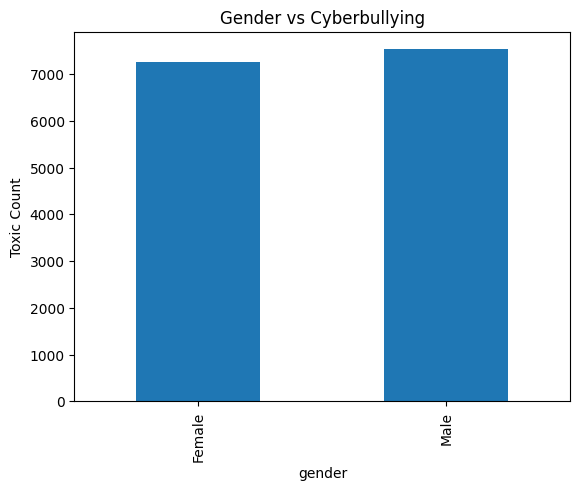

In [33]:
gender_analysis.plot(kind='bar')

plt.title("Gender vs Cyberbullying")

plt.ylabel("Toxic Count")

plt.show()

In [34]:
toxic_percentage = (df['toxic'].sum() / len(df)) * 100

print("Toxic Comment Percentage:", toxic_percentage)

Toxic Comment Percentage: 12.75806117517089


In [35]:
df['hour'] = np.random.randint(0,24,size=len(df))

In [36]:
hourly_toxic = df.groupby('hour')['toxic'].sum()

peak_hour = hourly_toxic.idxmax()

print("Peak Toxic Hour:", peak_hour)

Peak Toxic Hour: 12


In [37]:
most_harmful_platform = platform_analysis.idxmax()

print("Most Harmful Platform:", most_harmful_platform)

Most Harmful Platform: Instagram


In [38]:
df['user_id'] = np.random.randint(1000,2000,size=len(df))

In [39]:
user_toxicity = df.groupby('user_id')['toxic'].sum()

high_risk_users = user_toxicity[user_toxicity > 10]

print("High Risk User Count:", len(high_risk_users))

High Risk User Count: 867


In [40]:
cyberbullying_frequency = df['toxic'].sum()

print("Cyberbullying Frequency:", cyberbullying_frequency)

Cyberbullying Frequency: 14782
